In this notebook we demonstrate the performance of a U-Net machine learning model in predicting eddy kinetic energy.

Process:<br/>
    1) Load in a small sample of test data from a single region,<br/>
    2) Predict Eddy Kinetic Energy, <br/>
    3) Present some brief evaluation metrics.

In [43]:
from ml_model_ai4pex.model_setup import setup_scenario, \
      get_data, get_data_split
from ml_model_ai4pex.predict_model import predict_model

import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow logging

from matplotlib import pyplot as plt
import cmocean
import numpy as np
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import r2_score
import logging
import argparse


### Functions

In [44]:
def compute_scores(ds):

    r2 = np.zeros(ds.time_counter.size)
    ssim_pred = np.zeros(ds.time_counter.size)

    for i in range(ds.time_counter.size):

        r2[i] = r2_score(ds.fine_ke_true.isel(time_counter=i, var=0).to_numpy().flatten(), 
                    ds.fine_ke_pred.isel(time_counter=i, var=0).to_numpy().flatten())

        # now ssim score
        ssim_pred[i] = ssim(ds.fine_ke_true.isel(time_counter=i, var=0).to_numpy(), 
                    ds.fine_ke_pred.isel(time_counter=i, var=0).to_numpy(),
                    data_range = ds.fine_ke_pred.isel(time_counter=i, var=0).max().values-\
                            ds.fine_ke_pred.isel(time_counter=i, var=0).min().values,
                    )
        
    return r2, ssim_pred

### Setup
Create a null logger and define the arguments needed to run the UNet model.

In [45]:
# Null logger — discards all output
logger = logging.getLogger("notebook")
logger.handlers.clear()
logger.addHandler(logging.NullHandler())
logger.propagate = False

# Arguments for UNet prediction
args = argparse.Namespace(
    # Model architecture
    model="unet",
    features=["vor", "coarse_ke", "sa"],
    target=["fine_ke"],
    base_filters=64,
    depth=2,
    # Data paths
    data_dir="./sample_dataset_for_github/",
    data_filenames=[
        "sample_vor_{domain}.nc",
        "sample_eke_{domain}.nc",
        "sample_mke_{domain}.nc",
        "sample_sa_{domain}.nc",
        "mask_{domain}.nc",
    ],
    domain=["SO_JET"],
    # Model path
    model_dir="./sample_model/",
    model_filename="sample_model.keras",
    # Data split
    train=False,
    predict=True,
    train_ratio=0.1,
    val_ratio=0.1,
    test_ratio=0.8,
    train_stride=1,
    shuffle_seed=42,
    # Normalisation
    local_norm=True,
    norm_stats={
        "vor":          {"mean": -0.002294, "std": 0.1418},
        "coarse_ke_log": {"mean": -3.729,   "std": 1.733},
        "sa":           {"mean": 1.9,       "std": 0.6455},
    },
    # Prediction output
    predict_save_filename=None,
    predict_save_dir=None,
    # Misc
    verbose=False,
)

### Setup scenario

In [36]:
scenario = setup_scenario(args, logger)
scenario

Scenario(input_var=['vor', 'coarse_ke', 'sa'], target=['fine_ke'], filters=None, kernels=None, padding=None, dilation_rates=None, name=None, base_filters=64, depth=2)

### Load data

In [37]:
ds, sc = get_data(scenario, args, logger)
ds, sc

Scenario(input_var=['vor', 'coarse_ke', 'sa'], target=['fine_ke'], filters=None, kernels=None, padding=None, dilation_rates=None, name=None, base_filters=64, depth=2)
Scenario(input_var=['vor', 'coarse_ke', 'sa'], target=['fine_ke'], filters=None, kernels=None, padding=None, dilation_rates=None, name=None, base_filters=64, depth=2)


(<xarray.Dataset> Size: 794kB
 Dimensions:        (r: 1, y_c: 40, x_c: 40, t: 10)
 Coordinates:
     nav_lev        (r) float32 4B 5.034
     y_c            (r, y_c) int64 320B 7 8 9 10 11 12 13 ... 41 42 43 44 45 46
     x_c            (r, x_c) int64 320B 3 4 5 6 7 8 9 10 ... 36 37 38 39 40 41 42
     glamt          (r, y_c, x_c) float64 13kB 3.375 3.625 3.875 ... 12.88 13.12
     gphit          (r, y_c, x_c) float64 13kB -46.22 -46.22 ... -39.07 -39.07
   * t              (t) object 80B 0072-02-12 00:00:00 ... 0072-02-21 00:00:00
 Dimensions without coordinates: r
 Data variables:
     vor            (r, y_c, x_c, t) float64 128kB -0.3297 -0.5236 ... 0.001499
     fine_ke        (r, t, y_c, x_c) float64 128kB 0.005384 0.009347 ... 0.005918
     coarse_ke      (r, t, y_c, x_c) float64 128kB 0.05416 0.04896 ... 0.005359
     sa             (r, t, y_c, x_c) float64 128kB -1.851 -1.82 ... 0.601 0.5692
     coarse_ke_log  (r, t, y_c, x_c) float64 128kB 0.4692 0.411 ... -0.8655
     fine_k

### Split data
Split into validation and test sets. Since `args.train=False`, `get_data_split` returns `(ds_val, ds_test)`.

In [38]:
ds_val, ds_test = get_data_split(ds, args, logger)
ds_test

<xarray.Dataset> Size: 641kB
Dimensions:        (r: 1, y_c: 40, x_c: 40, t: 8)
Coordinates:
    nav_lev        (r) float32 4B 5.034
    y_c            (r, y_c) int64 320B 7 8 9 10 11 12 13 ... 41 42 43 44 45 46
    x_c            (r, x_c) int64 320B 3 4 5 6 7 8 9 10 ... 36 37 38 39 40 41 42
    glamt          (r, y_c, x_c) float64 13kB 3.375 3.625 3.875 ... 12.88 13.12
    gphit          (r, y_c, x_c) float64 13kB -46.22 -46.22 ... -39.07 -39.07
  * t              (t) object 64B 0072-02-14 00:00:00 ... 0072-02-21 00:00:00
Dimensions without coordinates: r
Data variables:
    vor            (r, y_c, x_c, t) float64 102kB -0.7317 -0.9755 ... 0.001499
    fine_ke        (r, t, y_c, x_c) float64 102kB 0.008987 0.02125 ... 0.005918
    coarse_ke      (r, t, y_c, x_c) float64 102kB 0.08752 0.0372 ... 0.005359
    sa             (r, t, y_c, x_c) float64 102kB -1.817 -1.759 ... 0.601 0.5692
    coarse_ke_log  (r, t, y_c, x_c) float64 102kB 0.7461 0.2525 ... -0.8655
    fine_ke_log    (r, t, y_c, x_c) float64 102kB -4.712 -3.851 ... -5.213 -5.13

### Predict EKE
Load the trained UNet model and generate predictions on the test set.

In [39]:
pred_ds = predict_model(sc, ds_test, args, logger)
pred_ds

Input shape: (None, 40, 40, 3)


Input shape: (8, 40, 40, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step


<xarray.Dataset> Size: 179kB
Dimensions:       (time_counter: 8, y: 40, x: 40, var: 1)
Coordinates:
  * time_counter  (time_counter) object 64B 0072-02-14 00:00:00 ... 0072-02-2...
    gphit         (y, x) float64 13kB -46.22 -46.22 -46.22 ... -39.07 -39.07
    glamt         (y, x) float64 13kB 3.375 3.625 3.875 ... 12.62 12.88 13.12
  * var           (var) <U11 44B 'fine_ke_log'
Dimensions without coordinates: y, x
Data variables:
    fine_ke_pred  (time_counter, y, x, var) float32 51kB 0.01627 ... 0.006076
    fine_ke_true  (time_counter, y, x, var) float64 102kB 0.008987 ... 0.005918
Attributes:
    Title:        fine_ke_log - predicted and truth
    Description:  Predicted fine_ke_log from coarse-grained data using CNN
    Units:        ['m$^2$/s$^2$']
    Source:       ./sample_model/sample_model.keras

### Evaluation in a Southern Ocean boundary current region

1) Plot EKE and difference,
2) Plot R2 and SSIM scores.

#### Plot EKE at instantaneous snapshot

Text(0.5, 1.0, 'EKE Difference (Pred - True)')

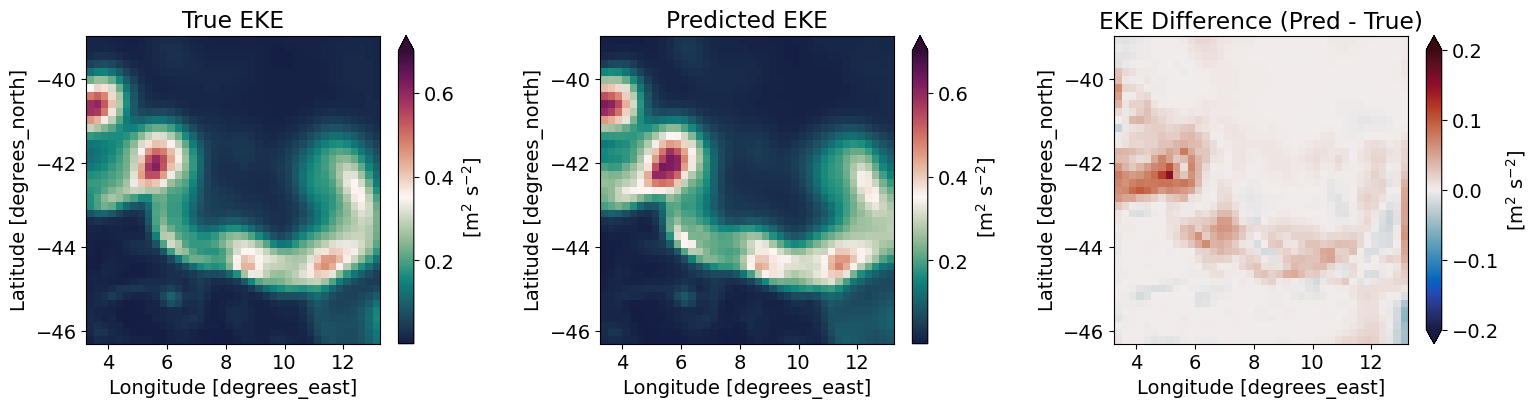

In [46]:
plt.rcParams.update({'font.size': 14})
fig = plt.figure(figsize=(18, 4))
gs = fig.add_gridspec(1, 3, wspace=0.4)
axs = gs.subplots()

vmin_eke = min(pred_ds.fine_ke_true.min().values, pred_ds.fine_ke_pred.min().values)
vmax_eke = max(pred_ds.fine_ke_true.max().values, pred_ds.fine_ke_pred.max().values)

pred_ds.fine_ke_true.isel(time_counter=0).plot(
    ax=axs[0],
    vmin=vmin_eke, vmax=vmax_eke,
    x='glamt', y='gphit',
    cmap=cmocean.cm.curl,
    cbar_kwargs={'label': '[m$^2$ s$^{-2}$]'},
    extend='max')
axs[0].set_title('True EKE')

pred_ds.fine_ke_pred.isel(time_counter=0).plot(
    ax=axs[1],
    vmin=vmin_eke, vmax=vmax_eke,
    x='glamt', y='gphit',
    cmap=cmocean.cm.curl,
    cbar_kwargs={'label': '[m$^2$ s$^{-2}$]'},
    extend='max')
axs[1].set_title('Predicted EKE')
axs[1].set_xlabel('Longitude [degrees_east]')
axs[1].set_ylabel('Latitude [degrees_north]')

diff = pred_ds.fine_ke_pred.isel(time_counter=0) - pred_ds.fine_ke_true.isel(time_counter=0)

diff.plot(
    ax=axs[2],
    vmin=-0.2, vmax=0.2,
    x='glamt', y='gphit',
    cmap=cmocean.cm.balance,
    cbar_kwargs={'label': '[m$^2$ s$^{-2}$]'},
    extend='both')
axs[2].set_title('EKE Difference (Pred - True)')

#### Plot R2 and SSIM score

On a small sample set of 8 timesteps, the unet model can predict a large proportion of the variance, given by the high R2 score. The high SSIM score shows true and predicted EKE fields are structurally similar.

In [41]:
r21, ssim1 = compute_scores(pred_ds)

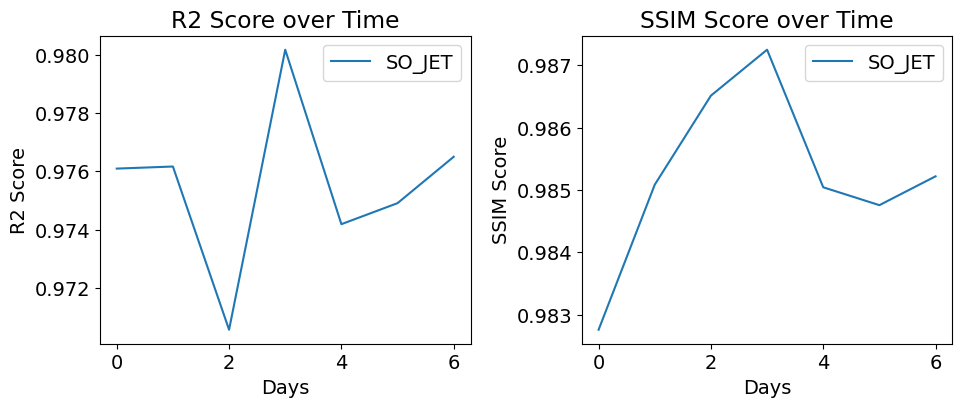

In [42]:
fig = plt.figure(figsize=(11, 4))
gs = fig.add_gridspec(1, 2, wspace=0.3)
axs = gs.subplots()

axs[0].plot(r21[:-1], label='SO_JET')
axs[0].set_title('R2 Score over Time')
axs[0].set_xlabel('Days')
axs[0].set_ylabel('R2 Score')
axs[0].legend()


axs[1].plot(ssim1[:-1], label='SO_JET')
axs[1].set_title('SSIM Score over Time')
axs[1].set_xlabel('Days')
axs[1].set_ylabel('SSIM Score')
axs[1].legend()

plt.tight_layout()